# Tensorflow-reconvolved image vs. original image by GalSim

In [1]:
%pylab inline
import galsim
import tensorflow as tf
import galflow as gf

Populating the interactive namespace from numpy and matplotlib


## Create galaxy model & convolve with a simple psf

In [2]:
gal_flux = 1.e5    # counts
gal_r0 = 1.0       # arcsec
g1 = 0.1           #
g2 = 0.2           #
pixel_scale = 0.2  # arcsec / pixel
img_size=256       # size of the stamp in pixels

psf_beta = 5       #
psf_re = 1.0       # arcsec


# Define the galaxy profile.
gal = galsim.Exponential(flux=gal_flux, scale_radius=gal_r0)
# To make sure that GalSim is not cheating, i.e. using the analytic formula of the light profile
# when computing the affine transformation, it might be a good idea to instantiate the image as
# an interpolated image.
# We also make sure GalSim is using the same kind of interpolation as us (bilinear for TF)
gal = galsim.InterpolatedImage(gal.drawImage(nx=img_size,ny=img_size, scale=pixel_scale),
                               x_interpolant='linear')


gal0 = gal.shear(g1=g1, g2=g2)

psf = galsim.Moffat(beta=psf_beta, flux=1., half_light_radius=psf_re)

gal = galsim.Convolve([gal0, psf])

Draw a GalSim image:

In [3]:
image_shear = gal.drawImage(nx=img_size,ny=img_size,scale=pixel_scale, method='no_pixel', use_true_center=False)

## Create observed image with noise:

In [4]:
noise = galsim.GaussianNoise().withVariance(10)
obs_imag = gal.drawImage(nx=img_size,ny=img_size, scale=pixel_scale, method='no_pixel')#, use_true_center=False)
noise.applyTo(obs_imag)

# Make noise image
noise_imag = galsim.Image(img_size,img_size, scale=pixel_scale)
noise.applyTo(noise_imag)

# Building observed image object
obs = galsim.InterpolatedImage(obs_imag)
nos = galsim.InterpolatedImage(noise_imag)

## We draw the PSF image in Kspace at the correct resolution

In [5]:
N = img_size
im_scale = pixel_scale
interp_factor=2
padding_factor=1
Nk = N*interp_factor*padding_factor
from galsim.bounds import _BoundsI

bounds = _BoundsI(-Nk//2, Nk//2-1, -Nk//2, Nk//2-1)


## PSF K-image
impsf = psf.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)
## PSF deconvolution kernel (1/PSF*)
ipsf = galsim.Deconvolve(psf)

# K-image of PSF deconv kernel
imipsf = ipsf.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)
# K-image of galaxy
imgal = obs.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)

# K-image of the noise
imnos = nos.drawKImage(bounds=bounds,
                       scale=2.*np.pi/(N*padding_factor* im_scale),
                       recenter=False)

## Convert all to TF tensors

In [6]:
tfimpsf = tf.convert_to_tensor(impsf.array, dtype=tf.complex64)
tfimipsf = tf.convert_to_tensor(imipsf.array, dtype=tf.complex64)
tfimgal = tf.convert_to_tensor(imgal.array, dtype=tf.complex64)
tfimnos = tf.convert_to_tensor(imnos.array, dtype=tf.complex64)

In [7]:
tfimgal = tf.expand_dims(tfimgal ,0)
tfimnos = tf.expand_dims(tfimnos ,0)
tfimpsf = tf.expand_dims(tfimpsf ,0)
tfimipsf = tf.expand_dims(tfimipsf ,0)
tfimpsf = tf.signal.fftshift(tfimpsf,axes=2)[:,:,:(img_size*interp_factor*padding_factor)//2+1]

## Deconvolve image

In [8]:
temp = tfimgal * tfimipsf
temp = tf.signal.fftshift(temp,axes=2)[:,:,:(img_size*interp_factor*padding_factor)//2+1]

## Reconvolve image

In [9]:
tst2 = gf.kconvolve(temp, tfimpsf)[...,0]
tst2 = tf.expand_dims(tf.signal.fftshift(tst2),-1)
tst2 = tf.image.resize_with_crop_or_pad(tst2, img_size, img_size)

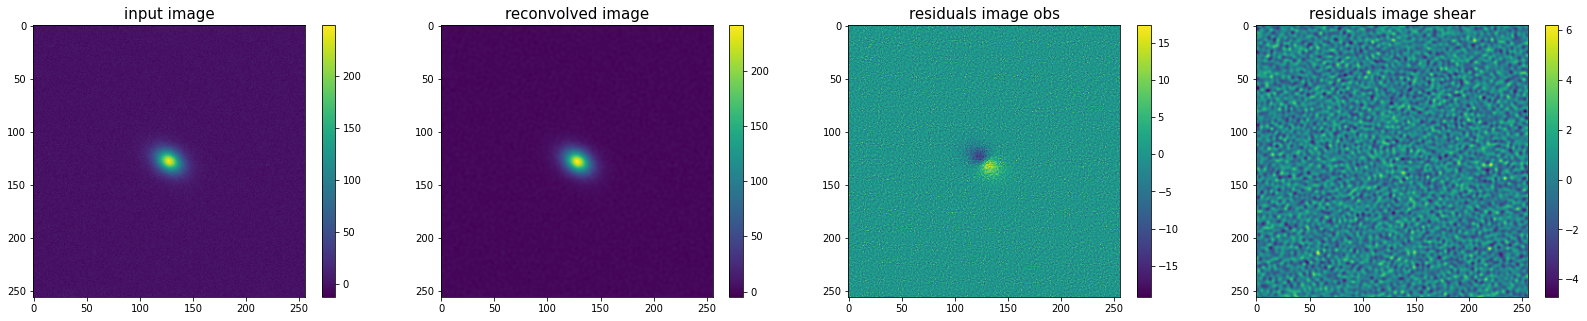

In [10]:
figure(figsize=[28,5])
subplot(141)
title('input image',fontsize=15)
imshow(obs_imag.array); colorbar();
subplot(142)
title('reconvolved image',fontsize=15)
imshow(tst2[0]);  colorbar();
subplot(143)
title('residuals image obs',fontsize=15)
imshow( (tst2[0,...,0] - obs_imag.array) ); colorbar();
subplot(144)
title('residuals image shear',fontsize=15)
imshow( (tst2[0,...,0] - image_shear.array) ); colorbar();